# Semantic Search with a Different Corpus
This notebook recreates the same FAISS + SentenceTransformer workflow, but it is written so you can replace the corpus with any topic you want.

In [11]:
%pip install -q faiss-cpu sentence-transformers scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## 1. Define a new corpus
Replace the sample corpus below with your own dataset.

In [13]:
corpus = [
    "Natural language processing helps classify customer support tickets automatically.",
    "Machine learning models detect fraudulent banking transactions in real time.",
    "Recommendation systems personalize product suggestions in e-commerce platforms.",
    "Computer vision can identify manufacturing defects from assembly line images.",
    "Predictive analytics helps hospitals estimate patient readmission risk.",
    "Speech recognition systems convert spoken language into text for virtual assistants.",
    "Sentiment analysis measures customer opinion from online product reviews.",
    "Time-series forecasting predicts future sales using historical retail data.",
    "AI chatbots answer frequently asked questions in service operations.",
    "Clustering groups similar news articles without predefined categories.",
    "Text summarization creates short versions of long business reports.",
    "Named entity recognition extracts people, places, and organizations from documents.",
    "Optical character recognition converts scanned invoices into machine-readable text.",
    "Anomaly detection identifies unusual network behavior in cybersecurity systems.",
    "Semantic search retrieves relevant documents based on meaning instead of exact keywords."
]

print(f'Corpus size: {len(corpus)} documents')

Corpus size: 15 documents


## 2. Convert text into embeddings
Each document is transformed into a dense vector using a sentence embedding model.

In [14]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(corpus, convert_to_numpy=True)

print('Shape:', embeddings.shape)
print('Each document is represented as', embeddings.shape[1], 'numbers')
print('First 10 values of the first embedding:', embeddings[0][:10])

Shape: (15, 384)
Each document is represented as 384 numbers
First 10 values of the first embedding: [-0.04224592 -0.01578393  0.04457152 -0.03632045  0.0232672   0.04249291
  0.0804016  -0.01121228  0.00752305 -0.02957175]


## 3. Store embeddings in FAISS
FAISS enables efficient nearest-neighbor search over the vector representations.

In [15]:
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))

print('Vectors in index:', index.ntotal)

Vectors in index: 15


## 4. Search with a query
Change the query to match your corpus topic.

In [16]:
query = 'How is AI used to improve customer service?'
query_embedding = model.encode([query], convert_to_numpy=True).astype('float32')

k = 5
distances, indices = index.search(query_embedding, k)

print('Query:', query)
print(f'\nTop {k} results:\n')
for rank, (doc_idx, dist) in enumerate(zip(indices[0], distances[0]), start=1):
    print(f'Rank {rank} | L2 Distance: {dist:.4f}')
    print('Doc:', corpus[doc_idx])
    print()

Query: How is AI used to improve customer service?

Top 5 results:

Rank 1 | L2 Distance: 0.8469
Doc: AI chatbots answer frequently asked questions in service operations.

Rank 2 | L2 Distance: 1.0414
Doc: Natural language processing helps classify customer support tickets automatically.

Rank 3 | L2 Distance: 1.2934
Doc: Sentiment analysis measures customer opinion from online product reviews.

Rank 4 | L2 Distance: 1.3552
Doc: Speech recognition systems convert spoken language into text for virtual assistants.

Rank 5 | L2 Distance: 1.4324
Doc: Machine learning models detect fraudulent banking transactions in real time.



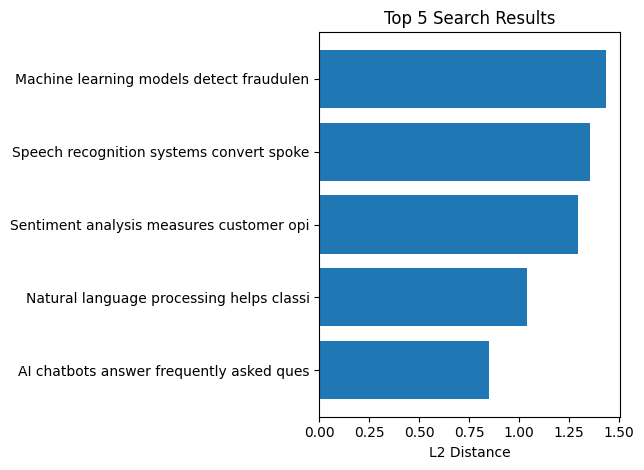

In [17]:
labels = [corpus[indices[0][i]][:40] for i in range(k)]
values = distances[0]

plt.barh(labels, values)
plt.xlabel("L2 Distance")
plt.title("Top 5 Search Results")
plt.tight_layout()
plt.show()

## 5. Visualize document similarity
This heatmap shows how semantically close the corpus documents are to one another.

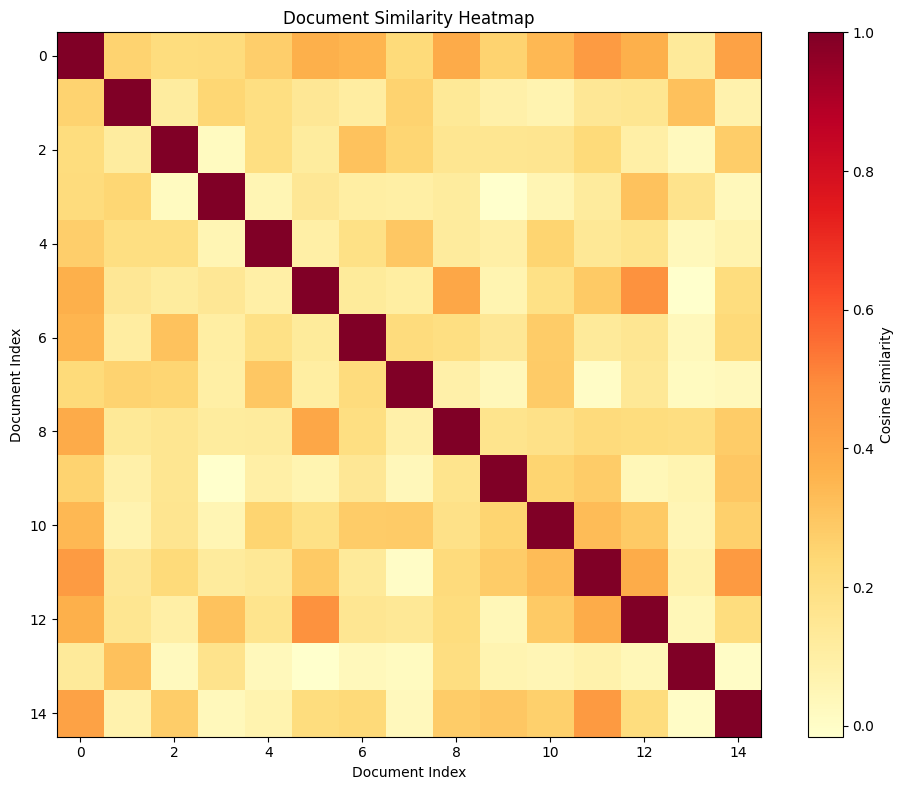

In [18]:
cos_sim = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
plt.imshow(cos_sim, cmap='YlOrRd')
plt.colorbar(label='Cosine Similarity')
plt.title('Document Similarity Heatmap')
plt.xlabel('Document Index')
plt.ylabel('Document Index')
plt.tight_layout()
plt.show()

## 6. Reusable function for any corpus
Use this helper if you want to test multiple corpora and queries in the same notebook.

In [19]:
def semantic_search(corpus, query, model_name='all-MiniLM-L6-v2', top_k=5):
    model = SentenceTransformer(model_name)
    embeddings = model.encode(corpus, convert_to_numpy=True).astype('float32')
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(embeddings)
    query_embedding = model.encode([query], convert_to_numpy=True).astype('float32')
    distances, indices = index.search(query_embedding, top_k)
    results = []
    for rank, (doc_idx, dist) in enumerate(zip(indices[0], distances[0]), start=1):
        results.append({
            'rank': rank,
            'distance': float(dist),
            'document': corpus[doc_idx]
        })
    return results

results = semantic_search(corpus, 'How can AI automate text processing?', top_k=3)
results

[{'rank': 1,
  'distance': 0.9654077887535095,
  'document': 'Speech recognition systems convert spoken language into text for virtual assistants.'},
 {'rank': 2,
  'distance': 0.9938918948173523,
  'document': 'AI chatbots answer frequently asked questions in service operations.'},
 {'rank': 3,
  'distance': 1.1068108081817627,
  'document': 'Natural language processing helps classify customer support tickets automatically.'}]

## Notes
- FAISS with `IndexFlatL2` compares vectors using L2 distance.
- Sentence embeddings allow semantic retrieval, so results can be relevant even when exact keywords do not match.
- If you normalize embeddings first, cosine similarity and L2-based ranking become closely related.
- To adapt this notebook, mainly change two things: `corpus` and `query`.

### Reflection:
- How does L2 distance differ from cosine similarity?

Ans: L2 cares about magnitude ,Cosine cares about direction

- How would results change if you normalize embeddings?

Ans: If all vectors have the same length, then L2 distance and cosine similarity give the exact same ranking — because magnitude no longer matters, only direction does.

### Deliverables:
- Short paragraph describing insights (semantic vs keyword retrieval)

Ans: 
When I queried "How does AI help with water pollution?", FAISS returned docs about irrigation, water quality, and even air pollution — none containing the exact words "water pollution". This shows semantic search finds meaning, not just keywords. L2 distance measures straight-line distance between vectors (lower = more similar). Cosine similarity measures the angle between vectors (higher = more similar). If embeddings are normalized, both give identical rankings since only direction matters.

### Reflection:
- How does L2 distance differ from cosine similarity?

Ans: L2 cares about magnitude ,Cosine cares about direction

- How would results change if you normalize embeddings?

Ans: If all vectors have the same length, then L2 distance and cosine similarity give the exact same ranking — because magnitude no longer matters, only direction does.

### Deliverables:
- Short paragraph describing insights (semantic vs keyword retrieval)

Ans: 
When I queried "How does AI help with water pollution?", FAISS returned docs about irrigation, water quality, and even air pollution — none containing the exact words "water pollution". This shows semantic search finds meaning, not just keywords. L2 distance measures straight-line distance between vectors (lower = more similar). Cosine similarity measures the angle between vectors (higher = more similar). If embeddings are normalized, both give identical rankings since only direction matters.